This is a notebook that aims to explore the difference is the proxies when created with different weight sets. 

## **Import & Setup**

In [1]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, itertools
from collections import defaultdict
import matplotlib.pyplot as plt

## **Help Functions**

In [2]:
# Function that creates a weighted Borda ensemble lookup of the 3 approaches
def build_lookup(df):
    lookup = {}
    for _, row in df.iterrows():
        lookup[row['NACE Code']] = [(row[p], 10 - i) for i, p in enumerate(TOPCOLS) if pd.notna(row[p])]
    return lookup  

In [10]:
# Function that receives the weight set and returns the ensembled top candidates
def ensemble(method_weights, k=10):
    weights_sum = sum(method_weights.values())
    normalized_weights = {method: weight / weights_sum for method, weight in method_weights.items()}
    final = {}
    
    # iterate through every nace code and score each candidate
    for nace_code in naces:
        neigh_scores = defaultdict(float)
        for method in LOOKUP:
            for neigh, pos_weight in LOOKUP[method].get(nace_code, []):
                neigh_scores[neigh] += normalized_weights[method] * pos_weight
        final[nace_code] = [t for t, _ in sorted(neigh_scores.items(), key=lambda x: (-x[1], x[0]))[:k]]
    return final

In [4]:
def mean_jaccard(A, Bd, k):
    v = [len(set(A[c][:k]) & set(Bd.get(c, [])[:k])) / len(set(A[c][:k]) | set(Bd.get(c, [])[:k]))
         for c in A if set(A[c][:k]) | set(Bd.get(c, [])[:k])]
    return float(np.mean(v))

## **Load the Data**

In [5]:
GT  = "../../06. Ground Truths Creation"
sup = pd.read_csv(f"{GT}/1. Supervised Approach/2. Approach 2 (won)/Extracted CSV Files/top10.csv")
uns = pd.read_csv(f"{GT}/2. Unsupervised Approach/2. Approach 2 (won)/Extracted CSV Files/top10.csv")
ssl = pd.read_csv(f"{GT}/3. Semi-Supervised Approach/1. Approach 1 (won)/Extracted CSV Files/top10.csv")
final = pd.read_csv(f"{GT}/4. Ensembling of Approaches/Extracted CSV Files/top10_final.csv")

DFS = {'supervised': sup, 'unsupervised': uns, 'ssl': ssl}
TOPCOLS = [f"Top{i}" for i in range(1, 11)]
naces = sorted(set().union(*[set(d['NACE Code']) for d in DFS.values()]))
print(f"{len(naces)} NACE codes across the three approaches")

306 NACE codes across the three approaches


## **Create the Fixed Proxies of each Approach**

In [6]:
# Get the top-10 of every approach
LOOKUP = {m: build_lookup(df) for m, df in DFS.items()}

## **Create the Reference Ensemble Proxies (Originally used in Thesis)**

In [9]:
# Find the original thesis weights
THESIS_WEIGHTS = {'supervised': 0.8148, 'unsupervised': 0.9379, 'ssl': 0.8667}
reference_proxies = ensemble(THESIS_WEIGHTS)
reference_proxies

{1.13: ['Metamorfosi',
  'Kato Lehonia',
  'Palaia',
  'Epta Platania - Oksigono',
  'Agioi Anargiroi',
  'Agia Paraskeui',
  'Agios Konstantinos',
  'Agios Vasilios',
  'Neapoli',
  'Analipsi'],
 1.3: ['Agia Paraskeui',
  'Epta Platania - Oksigono',
  'Neapoli',
  'Agios Vasilios',
  'Palaia',
  'Nea Ionia',
  'Agios Konstantinos',
  'Asteria Agrias',
  'Agia Kyriaki',
  'Aivaliotika'],
 1.49: ['Nees Pagases',
  'Dimini',
  'Melissatika',
  'Agios Georgios',
  'Neapoli',
  'Epta Platania - Oksigono',
  'Aivaliotika',
  'Agios Vasilios',
  'Alli Meria',
  'Agia Paraskeui'],
 1.61: ['Nees Pagases',
  'Epta Platania - Oksigono',
  'Dimitriada',
  'Aivaliotika',
  'Metamorfosi',
  'Agia Paraskeui',
  'Agios Georgios',
  'Analipsi',
  'Dimini',
  'Agios Konstantinos'],
 2.4: ['Metamorfosi',
  'Analipsi',
  'Asteria Agrias',
  'Agios Konstantinos',
  'Epta Platania - Oksigono',
  'Agia Paraskeui',
  'Agia Kyriaki',
  'Palaia',
  'Nees Pagases',
  'Aivaliotika'],
 3.11: ['Palaia',
  'Metamor

In [ ]:
# Sanity check: see if the resulting ensembling candidates match the ones
# used in the thesis orignially

_final = {r['NACE Code']: [r[c] for c in ['Top1','Top2','Top3'] if pd.notna(r[c])] for _, r in final.iterrows()}
check = np.mean([len(set(reference_proxies[c][:3]) & set(_final[c])) / max(1, len(set(reference_proxies[c][:3]) | set(_final[c])))
               for c in reference_proxies if c in _final])
wn = {m: v / sum(THESIS_WEIGHTS.values()) for m, v in THESIS_WEIGHTS.items()}

print(f"reference_proxies reproduces saved top10_final (top-3 Jaccard) = {check:.3f}  (expect 1.000)")
print(f"reference_proxies weights: sup={wn['supervised']:.3f}  unsup={wn['unsupervised']:.3f}  ssl={wn['ssl']:.3f}  (equal=0.333)")

reference_proxies reproduces saved top10_final (top-3 Jaccard) = 1.000  (expect 1.000)
reference_proxies weights: sup=0.311  unsup=0.358  ssl=0.331  (equal=0.333)


## **Ensemble for fixed scenarios**

Here we perform 4 test experiments for fixed cases: equal weights, and dominatig on the supervised/unsupervised/semi-supervised approach respectively. We compare each with the reference results

In [13]:
scenarios = {
    'equal':{'supervised':1,'unsupervised':1,'ssl':1},
    'sup_dominant':{'supervised':.6,'unsupervised':.2,'ssl':.2},
    'unsup_dominant':{'supervised':.2,'unsupervised':.6,'ssl':.2},
    'ssl_dominant':{'supervised':.2,'unsupervised':.2,'ssl':.6}
}

In [14]:
print("Jaccard vs reference:")
for name, weights in scenarios.items():
    proxies = ensemble(weights)
    print(f"  {name:15} J@3={mean_jaccard(reference_proxies, proxies, 3):.3f}  J@10={mean_jaccard(reference_proxies, proxies, 10):.3f}")

Jaccard vs reference:
  equal           J@3=0.926  J@10=0.975
  sup_dominant    J@3=0.686  J@10=0.783
  unsup_dominant  J@3=0.651  J@10=0.828
  ssl_dominant    J@3=0.819  J@10=0.941


## **Ensemble for random scenarios**

To get a broader perspective, we try 100 randdom weight sets to see the distribution of the similarity

In [17]:
rng = np.random.default_rng(42)
ensembles, j3, j10 = [], [], []

# ensemble 100 random weight sets
for _ in range(100):
    w1, w2, w3 = rng.dirichlet([1, 1, 1])
    ensemble_res = ensemble({'supervised': w1, 'unsupervised': w2, 'ssl': w3})
    ensembles.append(ensemble_res)
    j3.append(mean_jaccard(reference_proxies, ensemble_res, 3))
    j10.append(mean_jaccard(reference_proxies, ensemble_res, 10))

# extra santity check: compare 40 random sets between themselves
pair = [mean_jaccard(ensembles[i], ensembles[j], 10) for i, j in itertools.combinations(range(40), 2)]

print("100 random vs reference:")
print(f"J@3={np.mean(j3):.3f}±{np.std(j3):.3f} (min {np.min(j3):.3f})")
print(f"J@10={np.mean(j10):.3f}±{np.std(j10):.3f} (min {np.min(j10):.3f})")
print(f"reference-free pairwise J@10 (40 ensembles): {np.mean(pair):.3f}±{np.std(pair):.3f}")

100 random vs reference:
J@3=0.702±0.107 (min 0.414)
J@10=0.793±0.099 (min 0.621)
reference-free pairwise J@10 (40 ensembles): 0.781±0.123


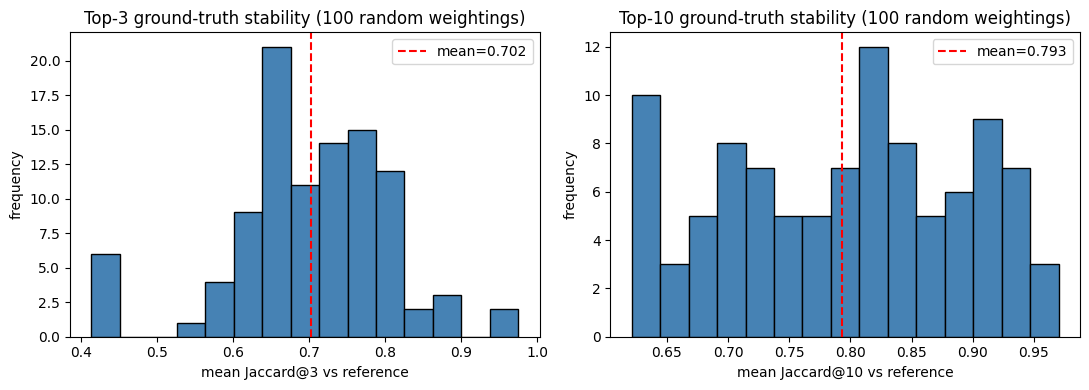

In [18]:
# Plot the results:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, vals, k in zip(ax, [j3, j10], [3, 10]):
    a.hist(vals, bins=15, color='steelblue', edgecolor='black')
    a.axvline(np.mean(vals), color='red', ls='--', label=f'mean={np.mean(vals):.3f}')
    a.set_title(f'Top-{k} ground-truth stability (100 random weightings)')
    a.set_xlabel(f'mean Jaccard@{k} vs reference'); a.set_ylabel('frequency'); a.legend()
plt.tight_layout(); plt.savefig('../results/proxy_weight_sensitivity.png', dpi=100, bbox_inches='tight'); plt.show()